# Regions across operations and formats: Side regions, XDMF sets, VTU/VTP field data

Added in v16.27.0:

- **Named Side regions survive operations.** A Side region names facets of cells (a Kratos condition, an Exodus side set, a Gmsh boundary). `refine`, `subdivide`, `convert_cells`, `decimate` and `repair` used to drop them; they now keep the facet, or the child facets that lie within it.
- **Regions in XDMF, VTU and VTP.** XDMF `<Set>` elements map to Point, Cell and Side regions; VTU and VTP write each region as a `region:<kind>:<name>` `<FieldData>` array.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')
TMP = tempfile.mkdtemp()


def to_grid(mesh):
    '''A PyVista grid of a meshio++ mesh, through a temporary .vtu.'''
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mesh)
    return pv.read(target)


def render(layers, title, view=(-1.0, -1.4, 0.8), size=(900, 560), ax=None, zoom=1.7):
    '''Render `(grid, kwargs)` layers with PyVista, or points with matplotlib when GL is unavailable.'''
    ax = ax or plt.figure(figsize=(9, 5.6)).add_subplot(111)
    try:
        pl = pv.Plotter(off_screen=True, window_size=size)
        for grid, kwargs in layers:
            pl.add_mesh(grid, **kwargs)
        pl.view_vector(view, viewup=(0, 0, 1))
        pl.reset_camera()
        pl.camera.zoom(zoom)
        ax.imshow(pl.screenshot(return_img=True))
        pl.close()
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)
        for grid, _ in layers:
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], s=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return ax

## A box with named Side regions

Two named facet groups on a 4x4x4 block of cubes, each cut into six tetrahedra: the `inlet` (every facet on the `x = 0` wall) and the `outlet` (the `x = 1` wall). Entries of a Side region are `(global cell index, local facet index)` pairs, the facet numbered as `detail/cell_faces.hpp` numbers the faces of the cell.

In [2]:
import itertools

from meshioplusplus._regions import Region

n = 4
g = np.linspace(0.0, 1.0, n + 1)
X, Y, Z = np.meshgrid(g, g, g, indexing='ij')
pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
idx = lambda i, j, k: (i * (n + 1) + j) * (n + 1) + k
# Six tetrahedra per cube around its main diagonal (Kuhn): the faces of neighbouring cubes agree.
tets = []
for i in range(n):
    for j in range(n):
        for k in range(n):
            for order in itertools.permutations(range(3)):
                corner = [i, j, k]
                path = [idx(*corner)]
                for axis in order:
                    corner[axis] += 1
                    path.append(idx(*corner))
                tets.append(path)
box = mp.Mesh(pts, [('tetra', np.array(tets))])

# Local facet numbering of a tetrahedron (detail/cell_faces.hpp), used by every Side region.
TET_FACETS = [(0, 1, 3), (1, 2, 3), (2, 0, 3), (0, 2, 1)]

# Select the facets lying wholly on a wall.
def wall_facets(mesh, axis, value):
    cells = mesh.cells[0].data
    out = []
    for c, tet in enumerate(cells):
        for f in range(4):
            corners = [tet[m] for m in TET_FACETS[f]]
            if np.allclose(mesh.points[corners][:, axis], value):
                out.append((c, f))
    return np.array(out)

box.regions = [
    Region('inlet', 'side', wall_facets(box, 0, 0.0), dim=2, tag=1),
    Region('outlet', 'side', wall_facets(box, 0, 1.0), dim=2, tag=2),
]
print({r.name: len(r.entries) for r in box.regions}, 'facets on', len(box.cells[0].data), 'tetrahedra')

{'inlet': 32, 'outlet': 32} facets on 384 tetrahedra


## `refine` keeps them

Uniform refinement splits every tetrahedron into eight; each parent facet on a wall becomes four child facets. `remap_region` keeps a facet's number only while its cell keeps its identity, and otherwise finds the facet again by its nodes.

{'inlet': 128, 'outlet': 128} facets on 3072 tetrahedra


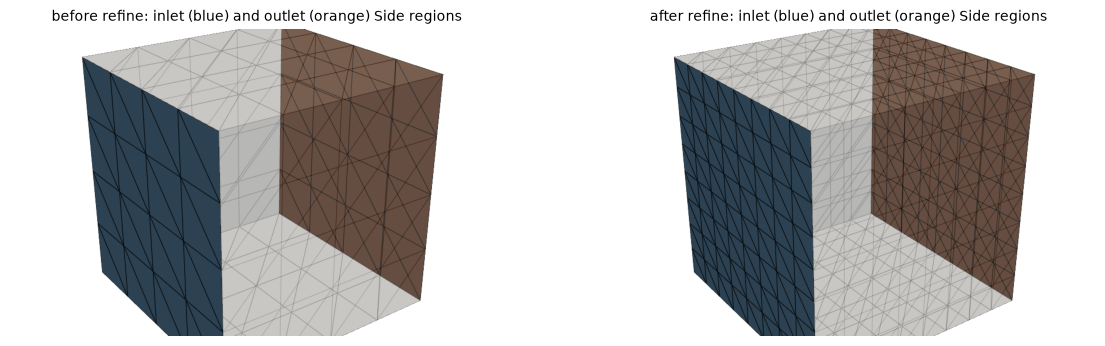

In [3]:
fine = mp.refine(box)
print({r.name: len(r.entries) for r in fine.regions}, 'facets on', len(fine.cells[0].data), 'tetrahedra')

def side_surface(mesh, name):
    '''The triangles of one Side region, as a mesh PyVista can draw.'''
    region = next(r for r in mesh.regions if r.name == name)
    cells = mesh.cells[0].data
    tris = [[cells[c][m] for m in TET_FACETS[f]] for c, f in region.entries]
    return mp.Mesh(mesh.points, [('triangle', np.array(tris))])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, mesh, title in ((axes[0], box, 'before refine'), (axes[1], fine, 'after refine')):
    render([
        (to_grid(mp.extract_surface(mesh)), dict(color='#e8e8e8', show_edges=True, opacity=0.35)),
        (to_grid(side_surface(mesh, 'inlet')), dict(color='#3182bd', show_edges=True)),
        (to_grid(side_surface(mesh, 'outlet')), dict(color='#e6550d', show_edges=True)),
    ], f"{title}: inlet (blue) and outlet (orange) Side regions", ax=ax, zoom=1.4)
plt.show()

## XDMF sets and VTU field data

The same regions round-trip through XDMF (as `<Set>` elements) and VTU (as `<FieldData>`), name, kind, `dim` and `tag` included.

In [4]:
for ext in ('.xdmf', '.vtu'):
    path = os.path.join(TMP, 'regions' + ext)
    mp.write(path, fine)
    back = mp.read(path)
    same = all(
        any(b.name == a.name and b.kind == a.kind and np.array_equal(np.asarray(b.entries), np.asarray(a.entries))
            for b in back.regions)
        for a in fine.regions
    )
    print(f"{ext}: {[(r.name, r.kind, len(r.entries)) for r in back.regions]}  identical to the source: {same}")

.xdmf: [('inlet', 'side', 128), ('outlet', 'side', 128)]  identical to the source: True
.vtu: [('inlet', 'side', 128), ('outlet', 'side', 128)]  identical to the source: True
